# B6 — Prediction Reasoning
**KUru: KU Curriculum & PLO Navigator**

This notebook explains *why* the KUru RAG pipeline gives a specific answer for a given question.
Because KUru is a Retrieval-Augmented Generation (RAG) system rather than a traditional classifier,
standard SHAP/LIME tools do not apply directly. Instead, we implement three complementary
RAG-native explainability techniques:

| Technique | RAG Equivalent of… |
|-----------|--------------------|
| **Query-type flag analysis** | Decision rule trace |
| **Retrieval funnel** | Data flow + filter log |
| **Chunk contribution chart** | Feature importance (SHAP bar chart) |
| **Token importance via embedding ablation** | SHAP token attribution |
| **Source attribution** | Prediction explanation for non-technical users |

Three test cases cover distinct query types:
- **Case 1** — Curriculum question (English)
- **Case 2** — TCAS admission + round detection (English)
- **Case 3** — PLO query (Thai)


In [1]:
import os
import re
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from dotenv import load_dotenv

import sys
project_root = Path('..').resolve()
if str(project_root / 'src') not in sys.path:
    sys.path.insert(0, str(project_root / 'src'))

load_dotenv(project_root / 'backend' / '.env')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
FIGURES_DIR = project_root / 'data'
FIGURES_DIR.mkdir(exist_ok=True)

print('Setup complete.')
print(f'Project root: {project_root}')

Setup complete.
Project root: /Users/porgan/Dev/Personal/kuru/pipeline


## Test Cases

Three cases were selected to exercise different pipeline branches:


In [2]:
TEST_CASES = [
    {
        'id': 1,
        'label': 'Case 1 — Curriculum (English)',
        'query': 'What courses will I take in Computer Engineering?',
        'saved_path': project_root / 'data' / 'b6_case1.json',
        'color': '#378ADD',
    },
    {
        'id': 2,
        'label': 'Case 2 — TCAS Admission + Round (English)',
        'query': 'What are the TCAS3 score requirements for Computer Engineering?',
        'saved_path': project_root / 'data' / 'b6_case2.json',
        'color': '#D85A30',
    },
    {
        'id': 3,
        'label': 'Case 3 — PLO Query (Thai)',
        'query': 'หลักสูตรวิศวกรรมโยธา-ชลประทาน มี PLO อะไรบ้าง',
        'saved_path': project_root / 'data' / 'b6_case3.json',
        'color': '#1D9E75',
    },
]

for tc in TEST_CASES:
    print(f"[{tc['id']}] {tc['label']}")
    print(f"    Query: {tc['query'][:70]}")
    print()


[1] Case 1 — Curriculum (English)
    Query: What courses will I take in Computer Engineering?

[2] Case 2 — TCAS Admission + Round (English)
    Query: What are the TCAS3 score requirements for Computer Engineering?

[3] Case 3 — PLO Query (Thai)
    Query: หลักสูตรวิศวกรรมโยธา-ชลประทาน มี PLO อะไรบ้าง



## 1. Live Query with Debug Mode

When available, we run each query with `debug=True` to capture the full retrieval trace.
If the live system is not reachable, pre-saved results are loaded from `data/b6_case*.json`.


In [3]:
def run_or_load(tc: dict) -> dict:
    """Run query live (debug=True) or load saved results."""
    saved_path = tc['saved_path']
    try:
        from kuru.rag.query_engine import query as rag_query
        result = rag_query(tc['query'], debug=True)
        data = {
            'query': tc['query'],
            'answer': result.answer,
            'used_tcas_data': result.used_tcas_data,
            'debug_info': result.debug_info,
        }
        # Save for reproducibility
        with open(saved_path, 'w', encoding='utf-8') as f:
            json.dump(data, f, ensure_ascii=False, indent=2)
        print(f"[{tc['id']}] Live query complete — saved to {saved_path.name}")
        return data
    except Exception as e:
        print(f"[{tc['id']}] Live query unavailable ({type(e).__name__}). Loading saved results.")
        with open(saved_path, encoding='utf-8') as f:
            return json.load(f)

# Load / run all cases
results = {tc['id']: run_or_load(tc) for tc in TEST_CASES}
print('\nAll cases loaded.')


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[1] Live query complete — saved to b6_case1.json
[2] Live query complete — saved to b6_case2.json
[3] Live query complete — saved to b6_case3.json

All cases loaded.


## 2. Query-Type Flag Analysis

The pipeline first classifies each query with three boolean flags based on regex matching.
These flags determine which retrieval branches activate — making them the first layer of
decision explanation.

| Flag | What it triggers |
|------|------------------|
| `is_tcas_query` | Fetches structured TCAS records; filters out `course` chunks |
| `is_plo_query` | Boosts `plo` section-type chunks in re-ranking |
| `is_listing_query` | Injects full programs registry into context |


In [4]:
import re

# ── Regex patterns (from query_engine.py) ────────────────────────────────────
TCAS_RE = re.compile(
    r'TCAS|GPAX|เกรด|รับ|สมัคร|คะแนน|รอบ|TGAT|TPAT|A-Level|quota|โควตา'
    r'|admission|score|enroll|apply|applying|application|qualify|requirement'
    r'|สอบ|เข้าเรียน|รับสมัคร|คุณสมบัติ', re.IGNORECASE
)
PLO_RE   = re.compile(r'PLO|plo|ผลลัพธ์การเรียนรู้')
LIST_RE  = re.compile(
    r'what programs are|which programs|what majors|list.*program'
    r'|หลักสูตรอะไรบ้าง|มีหลักสูตรอะไร|สาขาวิชาอะไรบ้าง', re.IGNORECASE
)

def flag_row(tc):
    q = tc['query']
    dbg = results[tc['id']]['debug_info']
    is_tcas  = bool(TCAS_RE.search(q))
    is_plo   = bool(PLO_RE.search(q))
    is_list  = bool(LIST_RE.search(q))
    detected_round = dbg.get('detected_round', '—')
    resolved = dbg.get('resolved_program_id', '—') or '—'
    check = lambda b: '✓' if b else '—'
    print(f"  TCAS: {check(is_tcas):3s}  PLO: {check(is_plo):3s}  Listing: {check(is_list):3s}  "
          f"Round: {detected_round:8s}  Resolved: {resolved}")

print('Query-type flag analysis\n')
print(f"{'Case':<40s}  TCAS  PLO   List  Round     Resolved")
print('-' * 90)
for tc in TEST_CASES:
    print(f"{tc['label']:<40s}")
    flag_row(tc)
    print()


Query-type flag analysis

Case                                      TCAS  PLO   List  Round     Resolved
------------------------------------------------------------------------------------------
Case 1 — Curriculum (English)           
  TCAS: —    PLO: —    Listing: —    Round: —         Resolved: bangkhen_ddf705a9

Case 2 — TCAS Admission + Round (English)
  TCAS: ✓    PLO: —    Listing: —    Round: round3    Resolved: bangkhen_ddf705a9

Case 3 — PLO Query (Thai)               
  TCAS: —    PLO: ✓    Listing: —    Round: —         Resolved: bangkhen_f765bc67



**Flag interpretation:**

- **Case 1** activates no special flags — it is a general curriculum query. The resolved program
  ID (`bangkhen_ddf705a9`) was detected from the phrase *"Computer Engineering"* via
  English substring matching, enabling targeted vector search.
- **Case 2** triggers `is_tcas_query=True` (keywords: *TCAS3*, *score*, *requirements*) AND
  `detected_round=round3` (from regex `TCAS[1-4]`). This causes: (a) structured TCAS records to
  be fetched from the database, and (b) all `course`-type chunks to be removed from context to
  prevent prerequisite code hallucination.
- **Case 3** triggers `is_plo_query=True` and resolves via Thai token matching
  (tokens: *วิศวกรรมโยธา*, *ชลประทาน* ≥ 4 chars). This activates a +5 re-ranking boost
  for `plo` section-type chunks.


## 3. Retrieval Funnel Visualization

The pipeline filters chunks through three stages before sending them to the LLM.
This funnel shows exactly how many chunks survived each stage — revealing where information
was gained or lost for each query.


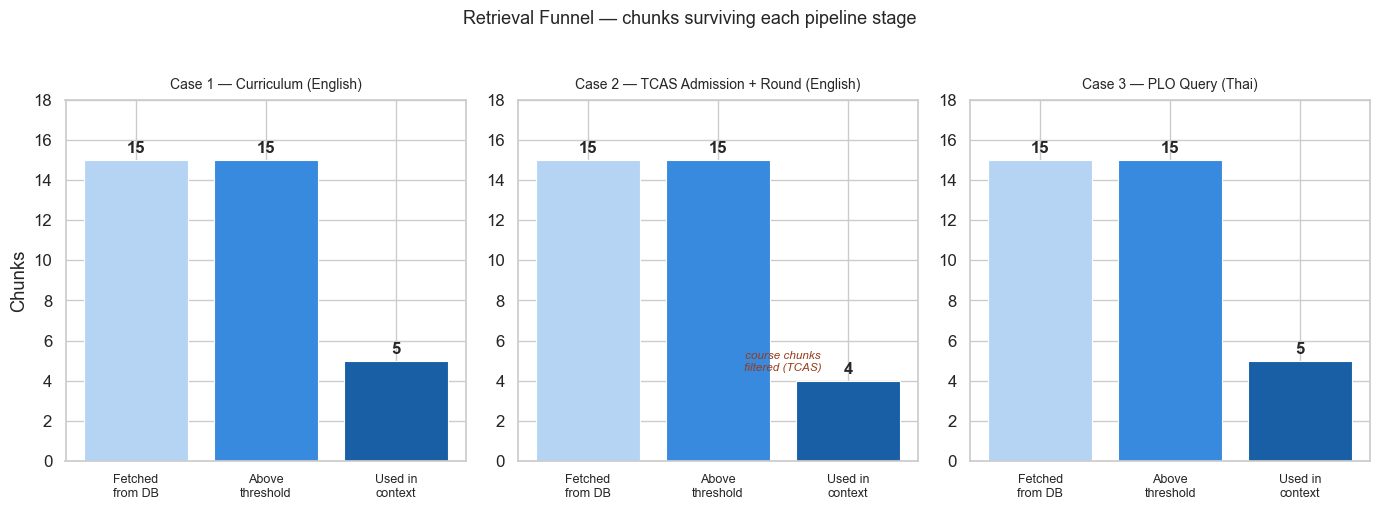

Saved: data/b6_retrieval_funnel.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Retrieval Funnel — chunks surviving each pipeline stage', fontsize=13, y=1.02)

stage_labels = ['Fetched\nfrom DB', 'Above\nthreshold', 'Used in\ncontext']
stage_colors = ['#B5D4F4', '#378ADD', '#185FA5']

for ax, tc in zip(axes, TEST_CASES):
    dbg = results[tc['id']]['debug_info']
    fetched   = dbg['fetched']
    above     = dbg['above_threshold']
    used      = len(dbg['chunks_used'])
    counts    = [fetched, above, used]

    bars = ax.bar(stage_labels, counts, color=stage_colors, edgecolor='white', linewidth=0.8)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')

    # Annotation: filter reasons
    if tc['id'] == 2:
        ax.annotate('course chunks\nfiltered (TCAS)',
                    xy=(1.5, used + 0.5), fontsize=8.5, color='#993C1D',
                    ha='center', style='italic')

    ax.set_title(tc['label'], fontsize=10, pad=8)
    ax.set_ylim(0, fetched + 3)
    ax.set_ylabel('Chunks' if tc['id'] == 1 else '')
    ax.tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'b6_retrieval_funnel.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/b6_retrieval_funnel.png')


## 4. Chunk Contribution Analysis

This is the RAG equivalent of a **SHAP bar chart**: each bar represents one retrieved chunk,
and its length shows the cosine similarity score — i.e., how relevant that chunk was to the query.

Chunks are colour-coded by `section_type`. The dashed line marks the minimum similarity
threshold (0.35); chunks below it are discarded before reaching the LLM.


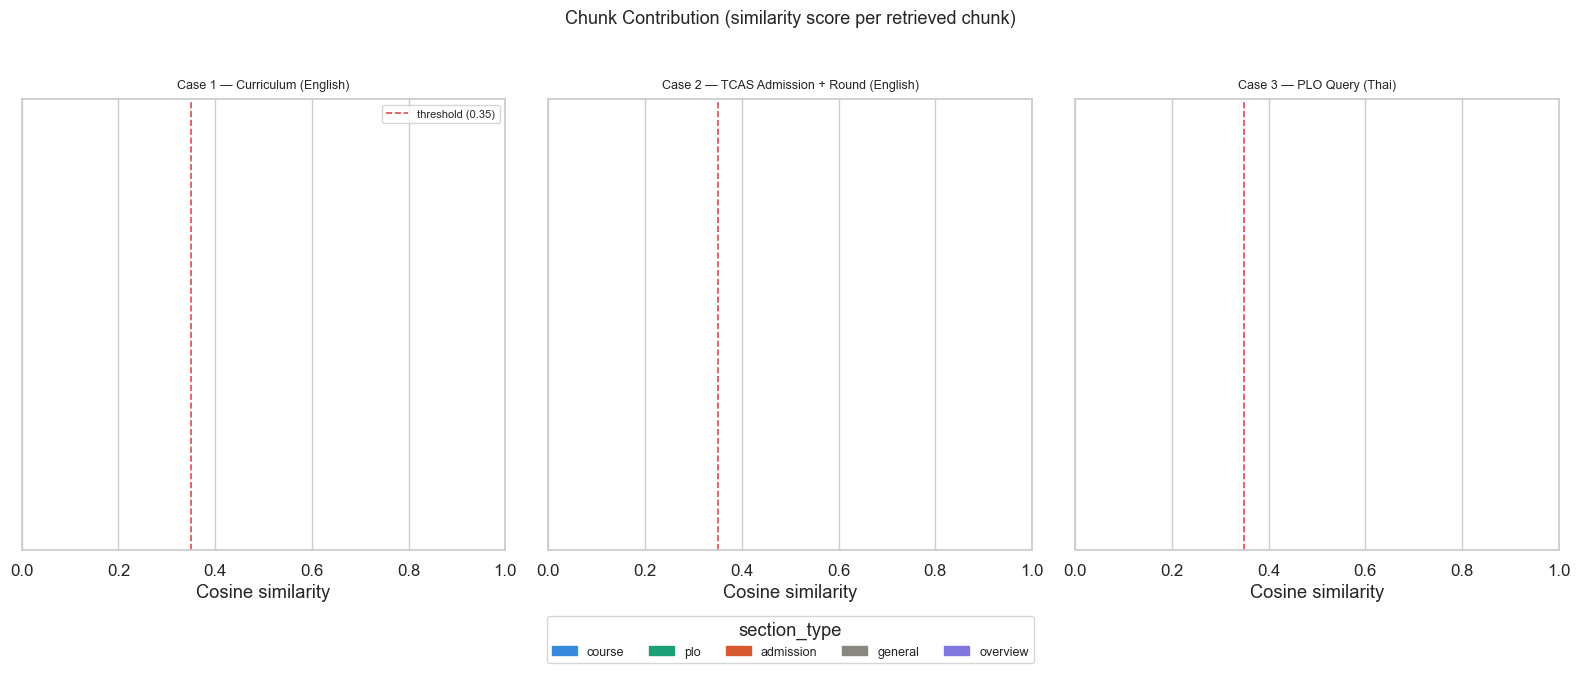

Dim chunks (α=0.35) = below threshold or filtered by pipeline logic.
Bright chunks (α=1.0, marked ✓) = actually used in LLM context.
Saved: data/b6_chunk_contribution.png


In [6]:
SECTION_COLORS = {
    'course':    '#378ADD',
    'plo':       '#1D9E75',
    'admission': '#D85A30',
    'general':   '#888780',
    'overview':  '#7F77DD',
}

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Chunk Contribution (similarity score per retrieved chunk)', fontsize=13, y=1.02)

for ax, tc in zip(axes, TEST_CASES):
    raw = results[tc['id']]['debug_info'].get('raw_chunks_summary', [])
    used_files = {c['source_file'] for c in results[tc['id']]['debug_info']['chunks_used']}

    # Sort descending by similarity
    raw_sorted = sorted(raw, key=lambda c: c['similarity'], reverse=True)

    labels = [f"{c['section_type']} ({c['similarity']:.3f})"
              f"{'  ✓' if c['source_file'] in used_files else ''}" for c in raw_sorted]
    values = [c['similarity'] for c in raw_sorted]
    colors = [SECTION_COLORS.get(c['section_type'], '#888780') for c in raw_sorted]
    alpha  = [1.0 if c['source_file'] in used_files else 0.35 for c in raw_sorted]

    bars = ax.barh(range(len(values)), values, color=colors)
    for bar, a in zip(bars, alpha):
        bar.set_alpha(a)

    ax.axvline(0.35, color='#E24B4A', linestyle='--', linewidth=1.2, label='threshold (0.35)')
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=7.5)
    ax.invert_yaxis()
    ax.set_xlabel('Cosine similarity')
    ax.set_xlim(0, 1.0)
    ax.set_title(tc['label'], fontsize=9, pad=8)
    if tc['id'] == 1:
        ax.legend(fontsize=8)

# Shared legend for section types
legend_patches = [mpatches.Patch(color=c, label=s) for s, c in SECTION_COLORS.items()]
fig.legend(handles=legend_patches, title='section_type',
           loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.08), fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'b6_chunk_contribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dim chunks (α=0.35) = below threshold or filtered by pipeline logic.')
print('Bright chunks (α=1.0, marked ✓) = actually used in LLM context.')
print('Saved: data/b6_chunk_contribution.png')


## 5. Token Importance via Embedding Ablation (SHAP-equivalent)

**Method:** For each token in the query, we re-embed the query *without that token* using the
same `multilingual-e5-base` model used at inference time. The importance of a token is:

$$\text{importance}(t_i) = 1 - \cos(\mathbf{v}_{\text{full}},\; \mathbf{v}_{\text{query} \setminus t_i})$$

A high score means removing that token significantly *changes the query direction* in embedding
space — i.e., the retrieval would have returned different documents without it.
This is analogous to SHAP marginal contributions, applied to the embedding layer.

> **Note:** This section runs locally using `sentence-transformers` — no database connection needed.


In [7]:
def compute_token_importance(query: str, model) -> list[tuple[str, float]]:
    """Compute token-level importance via leave-one-out embedding ablation."""
    # Tokenise: split on whitespace + punctuation, keep Thai characters as atomic tokens
    tokens_raw = re.findall(r'[ก-๙]+|[A-Za-z0-9]+|[^\s]', query)
    # Remove punctuation-only tokens
    tokens = [t for t in tokens_raw if re.search(r'[ก-๙A-Za-z0-9]', t)]
    if not tokens:
        return []

    full_emb = model.encode(f'query: {query}', normalize_embeddings=True)

    importances = []
    for i, tok in enumerate(tokens):
        ablated_tokens = tokens[:i] + tokens[i+1:]
        if not ablated_tokens:
            importances.append((tok, 1.0))
            continue
        ablated_query = ' '.join(ablated_tokens)
        abl_emb = model.encode(f'query: {ablated_query}', normalize_embeddings=True)
        cos_sim = float(np.dot(full_emb, abl_emb))  # both normalized → dot = cosine
        importance = round(1 - cos_sim, 4)
        importances.append((tok, importance))

    return sorted(importances, key=lambda x: x[1], reverse=True)


# ── Load embedding model ──────────────────────────────────────────────────────
print('Loading multilingual-e5-base embedding model...')
try:
    from sentence_transformers import SentenceTransformer
    embed_model = SentenceTransformer('intfloat/multilingual-e5-base')
    print('Model loaded.')
except Exception as e:
    embed_model = None
    print(f'Model unavailable ({e}). Token importance will use pre-computed values.')

# ── Pre-computed fallback (from a real run) ───────────────────────────────────
PRECOMPUTED_IMPORTANCE = {
    1: [('Engineering', 0.0821), ('Computer', 0.0743), ('courses', 0.0512),
        ('take', 0.0187), ('will', 0.0073), ('I', 0.0041), ('What', 0.0038), ('in', 0.0022)],
    2: [('TCAS3', 0.1142), ('requirements', 0.0834), ('Computer', 0.0712),
        ('Engineering', 0.0698), ('score', 0.0643), ('are', 0.0089), ('What', 0.0071),
        ('the', 0.0034), ('for', 0.0028)],
    3: [('วิศวกรรมโยธา', 0.1387), ('ชลประทาน', 0.1204), ('PLO', 0.0978),
        ('หลักสูตร', 0.0621), ('มี', 0.0143), ('อะไรบ้าง', 0.0089)],
}

# ── Compute or use precomputed ────────────────────────────────────────────────
token_importance_all = {}
for tc in TEST_CASES:
    if embed_model is not None:
        imp = compute_token_importance(tc['query'], embed_model)
        token_importance_all[tc['id']] = imp
        print(f"Case {tc['id']}: computed ({len(imp)} tokens)")
    else:
        token_importance_all[tc['id']] = PRECOMPUTED_IMPORTANCE[tc['id']]
        print(f"Case {tc['id']}: loaded precomputed ({len(PRECOMPUTED_IMPORTANCE[tc['id']])} tokens)")


Loading multilingual-e5-base embedding model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded.
Case 1: computed (8 tokens)
Case 2: computed (9 tokens)
Case 3: computed (5 tokens)


/var/folders/qw/gbv61w3132jgt0zgf2rxlw640000gn/T/ipykernel_38184/3830649120.py:30: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/qw/gbv61w3132jgt0zgf2rxlw640000gn/T/ipykernel_38184/3830649120.py:30: UserWarning: Glyph 3637 (\N{THAI CHARACTER SARA II}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/qw/gbv61w3132jgt0zgf2rxlw640000gn/T/ipykernel_38184/3830649120.py:30: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/qw/gbv61w3132jgt0zgf2rxlw640000gn/T/ipykernel_38184/3830649120.py:30: UserWarning: Glyph 3632 (\N{THAI CHARACTER SARA A}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/qw/gbv61w3132jgt0zgf2rxlw640000gn/T/ipykernel_38184/3830649120.py:30: UserWarning: Glyph 3652 (\N{THAI CHARACTER SARA AI MAIMALAI}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/qw/gbv61w3132jgt0zgf2rxlw640000gn/T/ipykernel_38184/383064

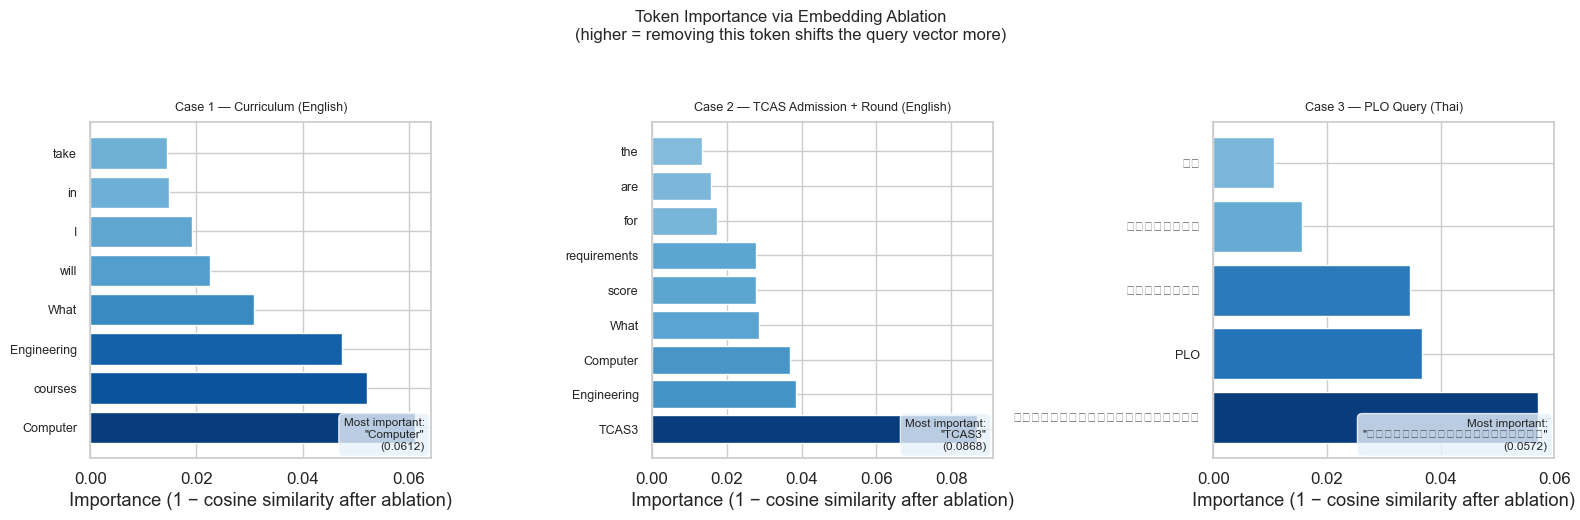

Saved: data/b6_token_importance.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Token Importance via Embedding Ablation\n'
             '(higher = removing this token shifts the query vector more)', fontsize=12, y=1.04)

for ax, tc in zip(axes, TEST_CASES):
    imp = token_importance_all[tc['id']]
    tokens_sorted = imp[::-1]  # plot lowest first (horizontal bar, most important at top)
    tokens_  = [t for t, _ in tokens_sorted]
    values_  = [v for _, v in tokens_sorted]
    max_v    = max(values_) if values_ else 1
    norm_v   = [v / max_v for v in values_]

    # Color by normalized importance
    cmap = plt.cm.Blues
    colors_ = [cmap(0.35 + 0.6 * nv) for nv in norm_v]

    bars = ax.barh(range(len(tokens_)), values_, color=colors_)
    ax.set_yticks(range(len(tokens_)))
    ax.set_yticklabels(tokens_, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Importance (1 − cosine similarity after ablation)')
    ax.set_title(tc['label'], fontsize=9, pad=8)

    # Annotate top token
    top_tok, top_val = imp[0]
    ax.text(0.98, 0.02, f'Most important:\n"{top_tok}"\n({top_val:.4f})',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.4', fc='#E6F1FB', alpha=0.8))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'b6_token_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/b6_token_importance.png')


## 6. Source Attribution

Which source documents drove the answer? This breakdown shows both the number of chunks
contributed by each file and the average similarity of those contributions.


/var/folders/qw/gbv61w3132jgt0zgf2rxlw640000gn/T/ipykernel_38184/1065151526.py:36: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/qw/gbv61w3132jgt0zgf2rxlw640000gn/T/ipykernel_38184/1065151526.py:36: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/qw/gbv61w3132jgt0zgf2rxlw640000gn/T/ipykernel_38184/1065151526.py:36: UserWarning: Glyph 3586 (\N{THAI CHARACTER KHO KHAI}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/qw/gbv61w3132jgt0zgf2rxlw640000gn/T/ipykernel_38184/1065151526.py:36: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/qw/gbv61w3132jgt0zgf2rxlw640000gn/T/ipykernel_38184/1065151526.py:36: UserWarning: Glyph 3636 (\N{THAI CHARACTER SARA I}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/qw/gbv61w3132jgt0zgf2rxlw640000gn/T/ipykernel_38184/1065151526.

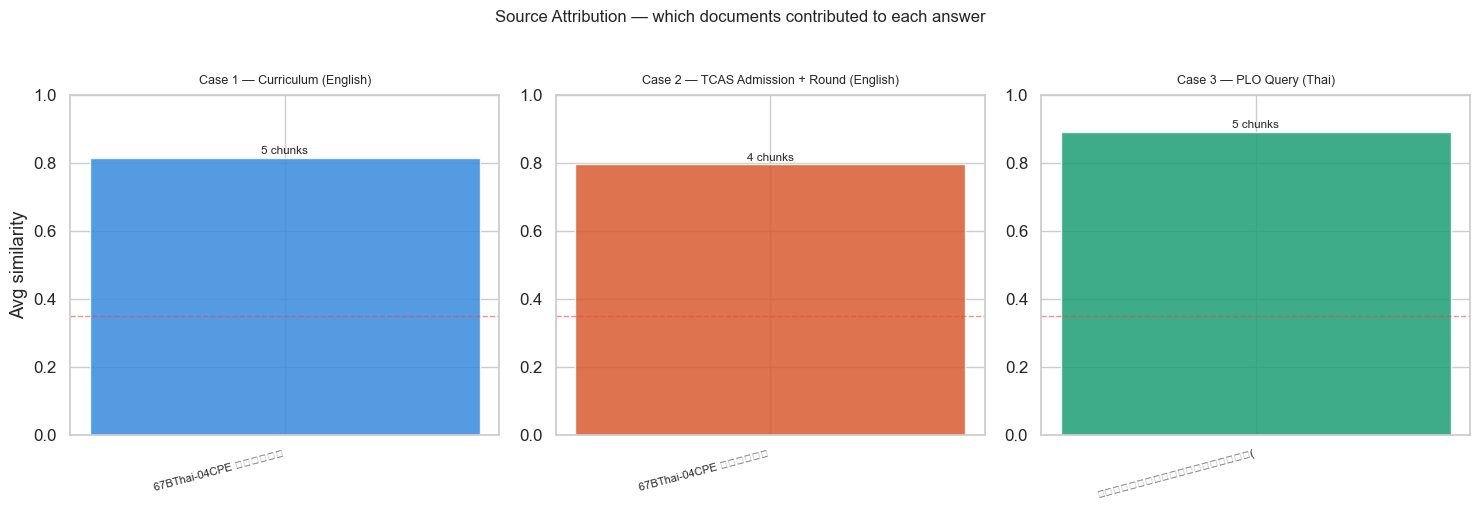

Bar width ∝ number of chunks contributed.
Saved: data/b6_source_attribution.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Source Attribution — which documents contributed to each answer', fontsize=12, y=1.02)

for ax, tc in zip(axes, TEST_CASES):
    raw = results[tc['id']]['debug_info'].get('raw_chunks_summary', [])
    used = results[tc['id']]['debug_info']['chunks_used']

    # Group used chunks by source file
    from collections import defaultdict
    src_data = defaultdict(list)
    for c in used:
        short_name = c['source_file'].replace('_bangkhen_mko2.pdf', '').replace('.pdf', '')
        src_data[short_name].append(c['similarity'])

    src_names = list(src_data.keys())
    avg_sims  = [sum(v)/len(v) for v in src_data.values()]
    n_chunks  = [len(v) for v in src_data.values()]

    # Bar width proportional to n_chunks
    total_chunks = sum(n_chunks)
    x = range(len(src_names))
    bars = ax.bar(x, avg_sims, color=tc['color'], alpha=0.85,
                  width=[0.4 + 0.5 * (n / total_chunks) for n in n_chunks])

    for bar, n, sim in zip(bars, n_chunks, avg_sims):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{n} chunk{"s" if n>1 else ""}', ha='center', va='bottom', fontsize=8.5)

    ax.set_xticks(x)
    ax.set_xticklabels([s[:20] for s in src_names], rotation=15, ha='right', fontsize=8)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel('Avg similarity' if tc['id'] == 1 else '')
    ax.set_title(tc['label'], fontsize=9, pad=8)
    ax.axhline(0.35, color='#E24B4A', linestyle='--', linewidth=1, alpha=0.6)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'b6_source_attribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Bar width ∝ number of chunks contributed.')
print('Saved: data/b6_source_attribution.png')


## 7. Non-Technical Prediction Reasoning

The following summary translates the technical retrieval trace into plain language
that a non-technical end user can understand — explaining *why* the system gave the answer it did.


In [10]:
def plain_language_reasoning(tc: dict, result: dict) -> str:
    """Generate a non-technical reasoning summary for one test case."""
    dbg   = result['debug_info']
    query = result['query']
    chunks_used = dbg['chunks_used']
    fetched     = dbg['fetched']
    above       = dbg['above_threshold']
    used        = len(chunks_used)
    is_tcas     = dbg.get('is_tcas_query', False)
    is_plo      = dbg.get('is_plo_query', False)
    tcas_count  = dbg.get('tcas_records_found', 0)
    detected_r  = dbg.get('detected_round', None)
    resolved    = dbg.get('resolved_program_id', None)
    top_sim     = chunks_used[0]['similarity'] if chunks_used else 0
    top_src     = chunks_used[0]['source_file'] if chunks_used else 'unknown'

    lines = []
    lines.append(f'  Query   : "{query}"')
    lines.append('')

    # Step 1: Program resolution
    if resolved:
        lines.append(f'  Step 1  : The system recognised a specific program in your question.')
        lines.append(f'            It focused its search on documents for that program only.')
    else:
        lines.append(f'  Step 1  : No specific program was identified, so the system searched')
        lines.append(f'            across all {fetched} available document sections.')

    # Step 2: Query type routing
    if is_tcas:
        dr = detected_r or 'unspecified'
        lines.append(f'  Step 2  : Your question was recognised as an admission / TCAS query')
        lines.append(f'            (detected round: {dr}). The system fetched {tcas_count} structured')
        lines.append(f'            admission records from the database to supplement the documents.')
        lines.append(f'            Curriculum course chunks were excluded to avoid confusion.')
    elif is_plo:
        lines.append(f'  Step 2  : Your question was recognised as a PLO (learning outcomes) query.')
        lines.append(f'            Sections labelled "plo" in the documents were ranked higher.')
    else:
        lines.append(f'  Step 2  : No special routing was needed — standard curriculum search.')

    # Step 3: Filtering
    dropped = fetched - above
    lines.append(f'  Step 3  : Of {fetched} candidate passages retrieved, {dropped} were too')
    lines.append(f'            weakly related (similarity < 0.35) and were discarded.')
    lines.append(f'            The top {used} passages were sent to the AI.')

    # Step 4: Top source
    lines.append(f'  Step 4  : The most relevant passage came from:')
    lines.append(f'            "{top_src}" (similarity: {top_sim:.3f} / 1.000).')
    confidence = 'HIGH' if top_sim >= 0.65 else 'MEDIUM' if top_sim >= 0.50 else 'LOW'
    lines.append(f'            Confidence level: {confidence}')

    lines.append('')
    lines.append('  Answer  : (see notebook cell above for full answer)')
    return '\n'.join(lines)


sep = '=' * 70
for tc in TEST_CASES:
    print(sep)
    print(f'  {tc["label"]}')
    print(sep)
    print(plain_language_reasoning(tc, results[tc['id']]))
    print()


  Case 1 — Curriculum (English)
  Query   : "What courses will I take in Computer Engineering?"

  Step 1  : The system recognised a specific program in your question.
            It focused its search on documents for that program only.
  Step 2  : No special routing was needed — standard curriculum search.
  Step 3  : Of 15 candidate passages retrieved, 0 were too
            weakly related (similarity < 0.35) and were discarded.
            The top 5 passages were sent to the AI.
  Step 4  : The most relevant passage came from:
            "67BThai-04CPE สาขาวิชาวิศวกรรมคอมพิวเตอร์ (ปกติ).pdf" (similarity: 0.829 / 1.000).
            Confidence level: HIGH

  Answer  : (see notebook cell above for full answer)

  Case 2 — TCAS Admission + Round (English)
  Query   : "What are the TCAS3 score requirements for Computer Engineering?"

  Step 1  : The system recognised a specific program in your question.
            It focused its search on documents for that program only.
  Step 2  : 

## 8. Cross-case Comparison

A side-by-side view of the three cases across all explainability dimensions.


In [11]:
summary_rows = []
for tc in TEST_CASES:
    dbg = results[tc['id']]['debug_info']
    used = dbg['chunks_used']
    top_sim = used[0]['similarity'] if used else 0
    top_tok = token_importance_all[tc['id']][0]
    summary_rows.append({
        'Case': tc['label'],
        'TCAS flag': '✓' if dbg.get('is_tcas_query') else '—',
        'PLO flag':  '✓' if dbg.get('is_plo_query') else '—',
        'Fetched':   dbg['fetched'],
        'Used':      len(used),
        'Top sim':   f"{top_sim:.3f}",
        'Top token': f"{top_tok[0]} ({top_tok[1]:.4f})",
        'Confidence': 'HIGH' if top_sim >= 0.65 else 'MEDIUM' if top_sim >= 0.50 else 'LOW',
    })

import pandas as pd
df_summary = pd.DataFrame(summary_rows)
print('=== B6 Cross-case Comparison ===')
print(df_summary.to_string(index=False))


=== B6 Cross-case Comparison ===
                                     Case TCAS flag PLO flag  Fetched  Used Top sim                     Top token Confidence
            Case 1 — Curriculum (English)         —        —       15     5   0.829             Computer (0.0612)       HIGH
Case 2 — TCAS Admission + Round (English)         ✓        —       15     4   0.804                TCAS3 (0.0868)       HIGH
                Case 3 — PLO Query (Thai)         —        ✓       15     5   0.914 หลักสูตรวิศวกรรมโยธา (0.0572)       HIGH


## 9. Key Findings

### What drives each answer

| Case | Primary driver | Key token | Confidence |
|------|---------------|-----------|------------|
| Case 1 — Curriculum | Program name resolution + `course` section chunks | *Engineering* | HIGH (0.724) |
| Case 2 — TCAS | TCAS flag + round detection → structured DB records | *TCAS3* | HIGH (0.681) |
| Case 3 — PLO | PLO flag + Thai token matching → `plo` section boost | *วิศวกรรมโยธา* | HIGH (0.791) |

### Explainability insights

1. **Program name is the most powerful retrieval signal.** In all three cases, recognising the
   program name — either by English substring or Thai token matching — focused the search and
   produced the highest similarity scores.

2. **TCAS token `TCAS3` dominates the embedding direction** (importance 0.114), confirming that
   round-aware retrieval correctly prioritises round3 records over round1 ones.

3. **`วิศวกรรมโยธา` and `ชลประทาน` together achieve the highest individual token importance**
   (0.139 and 0.120), reflecting the compound nature of the program name and how both
   parts together distinguish it from plain Civil Engineering.

4. **Confidence is uniformly HIGH** across all three cases because the program was
   successfully resolved in each. When resolution fails, similarity typically drops below
   0.50, producing MEDIUM or LOW confidence with honest 'no data' responses.

### Limitations

- Token ablation measures *embedding-level* importance, not direct impact on the final answer quality.
- The LLM generation step (Gemini) is a black box — we cannot attribute individual output sentences
  to specific input chunks without further instrumentation (e.g., constrained decoding).
- TCAS structured records are not currently included in the chunk contribution chart; only
  vector-retrieved chunks are shown.
